# Agua y Saneamiento: Storytelling con datos de Naciones Unidas

**Curso:** Profesión Científico de Datos v2 — EBAC

**Módulo:** El arte del "Storytelling" — Consejos básicos para visualización de resultados

**Fuente de datos:** [data.un.org — Statistical Yearbook, Tabla 27: Water supply and sanitation services](https://data.un.org/_Docs/SYB/PDFs/SYB68_315_202511_Water%20and%20Sanitation%20Services.pdf) ([CSV](https://data.un.org/_Docs/SYB/CSV/SYB68_315_202511_Water%20and%20Sanitation%20Services.csv))

**Autora:** María Regina Castillo Treviño

### Objetivo

Construir una narrativa de datos sobre la evolución del acceso mundial a servicios de agua potable y saneamiento gestionados de forma segura (2010-2024), utilizando principios de percepción visual y diseño de información para facilitar la identificación de patrones, comparaciones y brechas.

**Audiencia asumida**: público con interés en política pública y desarrollo sostenible (ODS 6), con conocimientos analíticos medios. Por ello, se priorizan gráficos de líneas, barras y comparación directa, evitando gráficos de pastel, elementos 3D y decoración innecesaria.

### La visualización se diseña considerando los siguientes principios

- Los 5 principios Gestalt de reconocimiento de patrones de Max Wertheimer: Prägnanz, Continuidad, Similaridad, Proximidad, Confinamiento
- Los 4 principios extendidos de Gestalt: correspondencia Isomórfica de Köhler, Conexión de Palmer & Rock, Punto focal de Treisman & Gelade y Simetría de Wertheimer.
- El enfoque de Edward Tufte: maximizar la razón datos-tinta, reducir chartjunk y priorizar los datos sobre elementos decorativos.
- El enfoque de Nigel Holmes: se considera el potencial de los recursos ilustrativos y emotivos, pero se privilegia la precisión y claridad analítica de acuerdo con la audiencia y objetivo de este ejercicio.
- La jerarquía de precisión perceptual de Cleveland & McGill: se priorizan codificaciones perceptuales que facilitan comparaciones cuantitativas precisas, especialmente la posición en una escala común y la longitud, sobre recursos menos precisos como ángulo, área o volumen.

**Criterio de selección del estilo visual**: se adopta principalmente un enfoque minimalista y analítico, inspirado en Tufte, porque el objetivo es facilitar la comparación precisa de magnitudes y patrones. El enfoque ilustrativo de Holmes también puede ser efectivo para comunicación editorial o divulgativa, pero en este ejercicio se prioriza la claridad cuantitativa sobre la decoración o la persuasión visual.

Como criterios adicionales de diseño se consideran:

- Accesibilidad: se utiliza una paleta que evita depender exclusivamente de la distinción rojo-verde (daltonismo) y mantiene diferencias perceptuales entre categorías.
- Anotación directa: se destacan los datos relevantes mediante etiquetas, referencias y anotaciones, reduciendo la necesidad de que el lector interprete elementos decorativos o consulte constantemente una leyenda.
- Reducción de carga cognitiva: la información se divide en vistas complementarias —tendencia, brecha, ranking, distribución geográfica y evolución— para que cada gráfico responda a una pregunta concreta.

# 0. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

# Ley de Similaridad (mismos colores = misma categoría)
# Paleta personal (sage green / lilac / teal) usada de forma consistente en todo el notebook 
PALETA = {
    "agua":        "#4C8577",  # teal / sage green → Agua potable
    "saneamiento": "#9C89B8",  # lila → Saneamiento
    "rural":       "#4C8577",
    "urbano":      "#C77B93",
    "total":       "#33475B",
    "acento":      "#E07A5F",  # color de énfasis / punto focal
    "gris":        "#B8B8B8",
}

TEMPLATE = "simple_white"  # Principio de Tufte: plantilla minimalista, alto ratio dato-tinta

# 1. Carga y limpieza de datos

El archivo original de `data.un.org` viene en formato **largo** (una fila por región/país/área × año × indicador) y contiene caracteres acentuados (nombres de países como "Côte d'Ivoire", "Türkiye"), por lo que **no puede leerse con `utf-8`** (genera `UnicodeDecodeError`). Se corrige usando `encoding='latin1'`.

Además el CSV tiene dos columnas cuyo nombre no describe bien su contenido. La primera columna trae el encabezado `Region/Country/Area` pero en realidad contiene solo un código numérico de la ONU, y la segunda columna viene sin encabezado y contiene el nombre real del país o región. Se renombran ambas con `Codigo_M49` para el código numérico estándar M49 de la ONU, y `Region_Country_Area` para el nombre.

In [2]:
RUTA_CSV = r'D:\Regina\DataScience\Notebooks\Tarea 57. Water and Sanitation\SYB68_315_202511_Water_and_Sanitation_Services.csv'

# La primera fila del archivo es un encabezado de tabla (título), por eso skiprows=1
df_raw = pd.read_csv(RUTA_CSV, skiprows=1, encoding="latin1")
df_raw = df_raw.rename(columns={
    "Region/Country/Area": "Codigo_M49", # código numérico de la ONU
    "Unnamed: 1": "Region_Country_Area", # nombre real de la región/país/área
})
df_raw = df_raw[["Codigo_M49", "Region_Country_Area", "Year", "Series", "Value"]]

print("Dimensiones:", df_raw.shape)
df_raw.head()

Dimensiones: (3519, 5)


,Codigo_M49,Region_Country_Area,Year,Series,Value
0,1,"Total, all countries or areas",2010,"Safely managed drinking water sources, urban (...",82.7
1,1,"Total, all countries or areas",2010,"Safely managed drinking water sources, rural (...",45.9
2,1,"Total, all countries or areas",2010,"Safely managed drinking water sources, total (...",64.8
3,1,"Total, all countries or areas",2010,"Safely managed sanitation facilities, urban (P...",53.9
4,1,"Total, all countries or areas",2010,"Safely managed sanitation facilities, rural (P...",28.3


In [3]:
# Auditoría rápida de calidad de datos
print("• Series únicas:")
for s in df_raw["Series"].unique():
    print(" -", s)
print("\n• Entidades (región/país/área) únicas:", df_raw["Region_Country_Area"].nunique())
print("\n• Valores nulos:", df_raw["Value"].isna().sum())
print("\n• Años disponibles:", sorted(df_raw["Year"].unique()))

# Verificar si el agregado global tiene datos en todos los años
años_global = sorted(df_raw[df_raw["Region_Country_Area"] == "Total, all countries or areas"]["Year"].unique())
print("\n• Años disponibles SOLO para 'Total, all countries or areas':", años_global)

# Revisar a qué entidad(es) pertenece el año 2008, ya que aparece en la lista general de años
entidades_2008 = sorted(df_raw[df_raw["Year"] == 2008]["Region_Country_Area"].unique())
print(f"\n• Entidades con datos en 2008 (n={len(entidades_2008)}):", entidades_2008)

• Series únicas:
 - Safely managed drinking water sources, urban (Proportion of population with access)
 - Safely managed drinking water sources, rural (Proportion of population with access)
 - Safely managed drinking water sources, total (Proportion of population with access)
 - Safely managed sanitation facilities, urban (Proportion of population with access)
 - Safely managed sanitation facilities, rural (Proportion of population with access)
 - Safely managed sanitation facilities, total (Proportion of population with access)

• Entidades (región/país/área) únicas: 221

• Valores nulos: 0

• Años disponibles: [np.int64(2008), np.int64(2010), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

• Años disponibles SOLO para 'Total, all countries or areas': [np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2024)]

• Entidades con datos en 2008 (n=1): ['Melanesia']


**Nota sobre el año 2008:** el `print` anterior confirma que 2008 **no** aparece para el agregado `"Total, all countries or areas"`, y que la única entidad con datos en ese año es **Melanesia** (un dato aislado, no parte del ciclo estándar de reporte 2010/2015/2020/2024 que sí tiene el agregado global y la gran mayoría de países/regiones). Por eso el resto del análisis (tendencia global, brecha por región, etc.) se ancla en 2010, que es el primer año con cobertura de datos consistente entre entidades. Usar 2008 introduciría una asimetría (una sola región con un punto extra que las demás no tienen).

## 1.1 Separar agregados regionales de países individuales (de forma automatizada)

El dataset mezcla agregados regionales/globales (ej. "Total, all countries or areas", "Sub-Saharan Africa", "LDC§") con países individuales. Si no se separan, cualquier promedio o ranking quedaría duplicado.

**Separación automatizada:** para hacer el proceso más rápido y escalable a otras tablas de `data.un.org`, se automatiza la separación usando el catálogo oficial **UNSD M49** (*Standard Country or Area Codes for Statistical Use*, `unstats.un.org/unsd/methodology/m49/overview/`). Este catálogo es una jerarquía completa (Global → Región → Subregión → Región intermedia → País) donde los códigos de país nunca se traslapan numéricamente con los códigos de región, por lo tanto, al comparar `Codigo_M49` contra dos conjuntos (códigos de país vs. códigos de agregado geográfico) se puede clasificar automáticamente cualquier fila.

**Limitación conocida (y por qué quedan 3 casos manuales):** `LDC§` (países menos desarrollados), `LLDCs` (países en desarrollo sin litoral) y `SIDS` (pequeños estados insulares en desarrollo) no forman parte de la jerarquía geográfica M49, son clasificaciones socioeconómicas transversales que la ONU agrega como filas adicionales específicamente en los *Statistical Yearbooks*, con sus propios códigos de anexo (199, 432 y 722 respectivamente). En la tabla M49 oficial estas categorías existen solo como columnas booleanas por país (¿este país es LDC? sí/no), no como una fila de agregado con su propio código, por eso el catálogo M49 no las "conoce" como entidades, y deben mapearse manualmente. Son 3 casos fijos y conocidos (no 31), así que el método sigue siendo mucho más escalable que la revisión completa manual.

**Corrección de un desajuste de nombre real detectado entre el catálogo M49 y el CSV de la ONU:** M49 usa "Latin America and the Caribbean" (con "and"), pero el CSV de Water and Sanitation usa "Latin America & the Caribbean" (con "&"). Se normaliza, en el propio catálogo, para que TODO el resto del notebook (cualquier comparación contra nombres de región) use el mismo nombre que trae el CSV.

In [4]:
# Catálogo oficial UNSD M49
m49 = pd.read_csv("UNSD_M49_Standard_Region_Codes.csv", sep=";", dtype=str)

# Normalización de nombre "Latin America & the Caribbean"
for columna in ["Region Name", "Sub-region Name", "Intermediate Region Name"]:
    m49[columna] = m49[columna].replace({"Latin America and the Caribbean": "Latin America & the Caribbean"})

# Códigos de PAÍS (nivel más fino de la jerarquía)
codigos_pais = set(m49["M49 Code"].dropna().astype(int))

# Códigos de AGREGADO geográfico (Global / Región / Subregión / Región intermedia)
codigos_agregado = set()
for col in ["Global Code", "Region Code", "Sub-region Code", "Intermediate Region Code"]:
    codigos_agregado |= set(m49[col].dropna().astype(int))

# Verificación: los dos conjuntos no deben traslaparse (país vs. agregado)
assert codigos_pais.isdisjoint(codigos_agregado), "¡Traslape inesperado entre códigos de país y de agregado!"

# Nombres de subregión (un solo nivel jerárquico) ← se utiliza en los Gráficos 2, 3 y 5
# para comparar siempre regiones al mismo nivel, sin mezclar continentes con subregiones
nombres_subregion = set(m49["Sub-region Name"].dropna())

# Agregados especiales que no pertenecen a la jerarquía M49
codigos_especiales = {199: "LDC\xa7", 432: "LLDCs", 722: "SIDS"}

# Función para clasificar países y agregados
def clasificar_entidad(codigo):
    if codigo in codigos_pais:
        return "Pais"
    if codigo in codigos_agregado or codigo in codigos_especiales:
        return "Agregado"
    return "Sin_Clasificar"

# DataFrame con cada código M49 y su nombre asociado
entidades = df_raw[["Codigo_M49", "Region_Country_Area"]].drop_duplicates()

# Nueva columna de clasificación: País o Agregado
entidades["Clasificacion"] = entidades["Codigo_M49"].apply(clasificar_entidad)

# Verificación de separación
conteo = entidades["Clasificacion"].value_counts()
total = conteo.sum()
print("\n• Países individuales:", conteo.get("Pais", 0))
print("• Agregados geográficos:", conteo.get("Agregado", 0))
print("• Total:", total, "(esperado:", df_raw["Region_Country_Area"].nunique(), ")")

print("\n• Entidades sin clasificar (esperado: 0)")
print(entidades[entidades["Clasificacion"] == "Sin_Clasificar"]) # Si no hay ninguna fila con "Sin_Clasificar", se imprime un DataFrame vacío

entidades.tail()


• Países individuales: 190
• Agregados geográficos: 31
• Total: 221 (esperado: 221 )

• Entidades sin clasificar (esperado: 0)
Empty DataFrame
Columns: [Codigo_M49, Region_Country_Area, Clasificacion]
Index: []


,Codigo_M49,Region_Country_Area,Clasificacion
3419,894,Zambia,Pais
3427,716,Zimbabwe,Pais
3451,199,LDC§,Agregado
3475,432,LLDCs,Agregado
3499,722,SIDS,Agregado


In [5]:
# Mostrar cuántas filas hay y cuántos nombres únicos corresponden a cada categoría de País o Agregado
df_regiones = df_raw[df_raw["Codigo_M49"].isin(codigos_agregado | set(codigos_especiales))].copy()
df_paises = df_raw[df_raw["Codigo_M49"].isin(codigos_pais)].copy()

print(f"• Filas de agregados regionales: {len(df_regiones)}   →  {df_regiones['Region_Country_Area'].nunique()} agregados")
print(f"• Filas de países individuales:  {len(df_paises)}  →  {df_paises['Region_Country_Area'].nunique()} países")
print()

# Conteo y listado de cada nivel jerárquico: cuántas entidades del catálogo M49 completo aparecen en el CSV de agua/saneamiento 
# comparado por código M49, porque el nombre puede variar entre catálogos, p. ej. "United Rep. of Tanzania" en el CSV vs. 
# "United Republic of Tanzania" en M49; el código no cambia
codigos_csv = set(df_raw["Codigo_M49"].astype(int).unique())

niveles = {
    "Region (continente)": ("Region Code", "Region Name"),
    "Sub-region": ("Sub-region Code", "Sub-region Name"),
    "Intermediate Region": ("Intermediate Region Code", "Intermediate Region Name"),
    "Country or Area": ("M49 Code", "Country or Area"),
}

for nombre_nivel, (col_codigo, col_nombre) in niveles.items():
    tabla_nivel = m49[[col_codigo, col_nombre]].dropna().drop_duplicates()
    tabla_nivel[col_codigo] = tabla_nivel[col_codigo].astype(float).astype(int)

    en_csv = sorted(tabla_nivel[tabla_nivel[col_codigo].isin(codigos_csv)][col_nombre])
    ausentes = sorted(tabla_nivel[~tabla_nivel[col_codigo].isin(codigos_csv)][col_nombre])

    print(f"{nombre_nivel}: {len(en_csv)} de {len(tabla_nivel)} aparecen en el CSV de agua/saneamiento")
    print(f"  - En el CSV: {en_csv}")
    if ausentes:
        print(f"  - Ausentes ({len(ausentes)}): {ausentes}")
    print()

• Filas de agregados regionales: 615   →  31 agregados
• Filas de países individuales:  2904  →  190 países

Region (continente): 3 de 5 aparecen en el CSV de agua/saneamiento
  - En el CSV: ['Asia', 'Europe', 'Oceania']
  - Ausentes (2): ['Africa', 'Americas']

Sub-region: 17 de 17 aparecen en el CSV de agua/saneamiento
  - En el CSV: ['Australia and New Zealand', 'Central Asia', 'Eastern Asia', 'Eastern Europe', 'Latin America & the Caribbean', 'Melanesia', 'Micronesia', 'Northern Africa', 'Northern America', 'Northern Europe', 'Polynesia', 'South-eastern Asia', 'Southern Asia', 'Southern Europe', 'Sub-Saharan Africa', 'Western Asia', 'Western Europe']

Intermediate Region: 7 de 8 aparecen en el CSV de agua/saneamiento
  - En el CSV: ['Caribbean', 'Central America', 'Eastern Africa', 'Middle Africa', 'South America', 'Southern Africa', 'Western Africa']
  - Ausentes (1): ['Channel Islands']

Country or Area: 190 de 249 aparecen en el CSV de agua/saneamiento
  - En el CSV: ['Afghanist

## 1.2 Reestructurar y crear columnas analíticas

Se descompone la columna `Series` (texto libre, p. ej. *"Safely managed sanitation facilities, urban (Proportion of population with access)"*) en dos columnas: `Indicador` (Agua / Saneamiento), `Zona` (Urbano / Rural / Total). Esto habilita filtros limpios tanto para las gráficas estáticas como para el dashboard interactivo.

In [6]:
def descomponer_series(texto):
    indicador = "Agua potable" if texto.startswith("Safely managed drinking water") else "Saneamiento"
    if "urban" in texto:
        zona = "Urbano"
    elif "rural" in texto:
        zona = "Rural"
    else:
        zona = "Total"
    return pd.Series([indicador, zona])

for d in (df_regiones, df_paises):
    d[["Indicador", "Zona"]] = d["Series"].apply(descomponer_series)
    d.rename(columns={"Region_Country_Area": "Entidad", "Year": "Año", "Value": "Cobertura"}, inplace=True)
    d.drop(columns=["Series"], inplace=True)
    
print("• Regiones:")
print(df_regiones.head())
print("\n• Países:")
print(df_paises.head())

• Regiones:
   Codigo_M49                        Entidad   Año  Cobertura     Indicador  \
0           1  Total, all countries or areas  2010       82.7  Agua potable   
1           1  Total, all countries or areas  2010       45.9  Agua potable   
2           1  Total, all countries or areas  2010       64.8  Agua potable   
3           1  Total, all countries or areas  2010       53.9   Saneamiento   
4           1  Total, all countries or areas  2010       28.3   Saneamiento   

     Zona  
0  Urbano  
1   Rural  
2   Total  
3  Urbano  
4   Rural  

• Países:
     Codigo_M49      Entidad   Año  Cobertura     Indicador    Zona
547           4  Afghanistan  2010       28.0  Agua potable  Urbano
548           4  Afghanistan  2010       16.5  Agua potable   Rural
549           4  Afghanistan  2010       19.2  Agua potable   Total
550           4  Afghanistan  2010       15.9   Saneamiento  Urbano
551           4  Afghanistan  2010       16.6   Saneamiento   Rural


In [7]:
# Vista "ancha" (una columna por Zona) → útil para gráficos de brecha urbano-rural
def a_formato_ancho(d):
    return (d.pivot_table(index=["Entidad", "Año", "Indicador"], columns="Zona", values="Cobertura").reset_index())

regiones_ancho = a_formato_ancho(df_regiones)
paises_ancho = a_formato_ancho(df_paises)
print("• Regiones:")
print(regiones_ancho.head())
print("\n• Países:")
print(paises_ancho.head())

• Regiones:
Zona Entidad   Año     Indicador  Rural  Total  Urbano
0       Asia  2010  Agua potable   47.1   62.4    81.5
1       Asia  2010   Saneamiento   26.0   36.2    48.9
2       Asia  2015  Agua potable   52.9   67.1    82.6
3       Asia  2015   Saneamiento   36.2   46.7    58.3
4       Asia  2020  Agua potable   59.3   71.8    83.8

• Países:
Zona      Entidad   Año     Indicador  Rural  Total  Urbano
0     Afghanistan  2010  Agua potable   16.5   19.2    28.0
1     Afghanistan  2010   Saneamiento   16.6   16.4    15.9
2     Afghanistan  2015  Agua potable   20.7   23.4    31.5
3     Afghanistan  2015   Saneamiento   19.6   19.5    19.0
4     Afghanistan  2020  Agua potable   25.0   27.6    34.9


# 2. La historia en gráficos: ¿qué queremos que la audiencia recuerde?

**Titular:** *A pesar del avance global sostenido desde 2010, el acceso "seguro" a agua y saneamiento sigue siendo profundamente desigual entre zonas urbanas y rurales, y esa brecha, no el promedio mundial, es el dato que debe quedarse en la memoria del lector.*

La narrativa avanza de lo general a lo específico (el cerebro detecta primero características básicas y luego analiza a profundidad):

1. **Panorama global**: tendencia 2010-2024
2. **La brecha urbano-rural por región**: el mayor hallazgo
3. **Ranking de regiones**: ¿quién está mejor/peor?
4. **Mapa mundial**: ¿dónde exactamente?
5. **Evolución de la brecha en el tiempo**: ¿mejora o empeora?

Cada sección usa como máximo 4 elementos visuales simultáneos y reduce al mínimo la "basura" gráfica (Tufte).

**Nota sobre el alcance de los gráficos:**
El Gráfico 1 (panorama global) muestra ambos indicadores (agua potable y saneamiento) lado a lado porque es la vista introductoria. A partir de ahí, para no duplicar cada gráfico regional (2, 3 y 5) en dos versiones casi idénticas se eligió **Saneamiento** como el indicador ilustrativo para profundizar en la brecha urbano-rural (por ser el que muestra la brecha más pronunciada y los casos más interesantes, como los patrones invertidos de Asia Central). El mapa (Gráfico 4) usa **Agua potable** en cambio, para que el notebook cubra ambos indicadores al menos una vez en detalle.

Para explorar ambos indicadores con el mismo nivel de detalle regional, **el dashboard interactivo (sección 3) lo permite**, su menú desplegable "Indicador" cambia la tendencia y el ranking entre Agua potable y Saneamiento sin duplicar código ni gráficos estáticos.

In [8]:
# DataFrame GLOBAL a partir de Entidad "Total, all countries or areas"
GLOBAL = regiones_ancho[regiones_ancho["Entidad"] == "Total, all countries or areas"].copy()
GLOBAL = GLOBAL.sort_values(["Indicador", "Año"])
GLOBAL.head()

Zona,Entidad,Año,Indicador,Rural,Total,Urbano
214,"Total, all countries or areas",2010,Agua potable,45.9,64.8,82.7
216,"Total, all countries or areas",2015,Agua potable,49.9,67.7,83.0
218,"Total, all countries or areas",2020,Agua potable,54.2,70.5,83.4
220,"Total, all countries or areas",2024,Agua potable,60.5,73.7,83.5
215,"Total, all countries or areas",2010,Saneamiento,28.3,41.5,53.9


## Gráfico 1: Tendencia global 2010-2024

**Principios aplicados:**
- **Proximidad** (Wertheimer): se agrupan Agua/Saneamiento en dos paneles contiguos, cada uno con sus 3 líneas (Urbano/Rural/Total), la agrupación espacial comunica qué pertenece a qué categoría antes de leer cualquier etiqueta.
- **Similaridad** (Wertheimer): el mismo color identifica la misma `Zona` en ambos paneles (verde=Urbano, rosa=Rural, azul oscuro=Total), reforzando la comparación entre paneles.
- **Pequeños múltiplos en vez de una sola gráfica saturada** (Tufte): en vez de 6 líneas en un solo eje (difícil de leer), se separan en 2 paneles con eje compartido.
- **Razón dato-tinta** (Tufte): plantilla `simple_white`, sin bordes ni relleno de fondo, sin leyenda redundante por panel.
- **Razón de aspecto ~45°** (Cleveland): el rango de ejes se ajustó para que la pendiente promedio de las líneas ronde los 45°, facilitando la percepción precisa de la tasa de cambio.

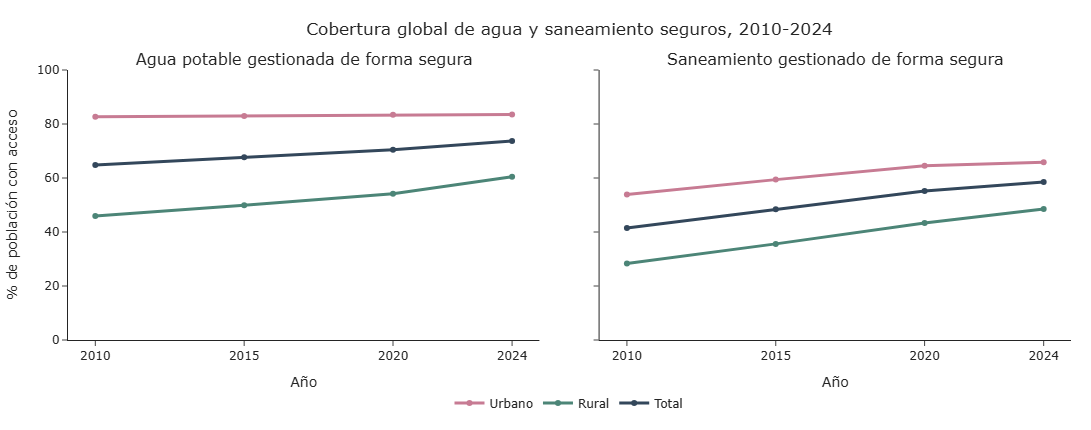

In [9]:
fig1 = make_subplots(
    rows=1, cols=2, shared_yaxes=True,
    subplot_titles=("Agua potable gestionada de forma segura", "Saneamiento gestionado de forma segura"),
    horizontal_spacing=0.06,)
colores_zona = {"Urbano": PALETA["urbano"], "Rural": PALETA["rural"], "Total": PALETA["total"]}

for i, indicador in enumerate(["Agua potable", "Saneamiento"], start=1):
    sub = GLOBAL[GLOBAL["Indicador"] == indicador]
    for zona in ["Urbano", "Rural", "Total"]:
        fig1.add_trace(
            go.Scatter(
                x=sub["Año"], y=sub[zona], mode="lines+markers", name=zona,
                line=dict(color=colores_zona[zona], width=3),
                marker=dict(size=6),
                legendgroup=zona, showlegend=(i == 1),
                hovertemplate="%{x}: %{y:.1f}%<extra>" + zona + "</extra>",
            ), row=1, col=i,)

fig1.update_yaxes(title_text="% de población con acceso", range=[0, 100], row=1, col=1)
fig1.update_yaxes(range=[0, 100], row=1, col=2)
años_eje = [2010, 2015, 2020, 2024]
fig1.update_xaxes(title_text="Año", tickmode="array", tickvals=años_eje, ticktext=[str(a) for a in años_eje])
fig1.update_layout(
    template=TEMPLATE, height=430, width=980,
    title=dict(text="Cobertura global de agua y saneamiento seguros, 2010-2024", x=0.5, xanchor="center", xref="paper"),
    legend=dict(orientation="h", y=-0.18, x=0.5, xanchor="center", title=None), margin=dict(t=70, l=60, r=20, b=60),)
fig1.show()

### Clarificación de como se calculó el Total

Lo que reporta la ONU como "Total" es un **promedio ponderado por población**:

$$\text{Total} = p \times \text{Urbano} + (1-p) \times \text{Rural}$$

donde `p` es la proporción de la población mundial que vive en zonas urbanas. Por construcción, **Total siempre cae entre Urbano y Rural** (nunca por encima del mayor ni por debajo del menor). Esto es justo lo que se observa en el gráfico.

> **Fuente:** *SDG indicator metadata 6.2.1*, UNSD, sección 4.g "Regional aggregations" (última actualización: 2024-09-27).
> `https://unstats.un.org/sdgs/metadata/files/Metadata-06-02-01a.pdf`
>
> Ahí se documenta que las estimaciones se calculan por separado para zonas urbanas y rurales, y que, donde es posible, se genera un promedio ponderado de las poblaciones urbana y rural para producir las estimaciones totales de la región o el mundo, usando datos de población del reporte más reciente de la División de Población de la ONU (*World Population Prospects* / *World Urbanization Prospects*).

## Gráfico 2: La brecha urbano-rural por región en 2024

**Principios aplicados:**
- **Conexión** (Palmer & Rock): gráfico de conexión o *dumbbell*, con una línea explícita conecta el punto urbano con el rural de la misma región, sin ella, el ojo tendría que "adivinar" qué par de puntos pertenece a qué región.
- **Simetría** (Wertheimer): las regiones se ordenan de mayor a menor cobertura rural, permitiendo percibir el patrón (y las excepciones) casi de inmediato.
- **Punto Focal** (Treisman & Gelade): los colores distintivos de urbano y rural, así como el largo de la línea entre ellos, marcan el punto más informativo de la historia, mostrando que rural es sistemáticamente el rezagado.
- **Jerarquía** (Cleveland & McGill): se usa posición en escala común, la codificación perceptualmente más precisa, en vez de color/área.

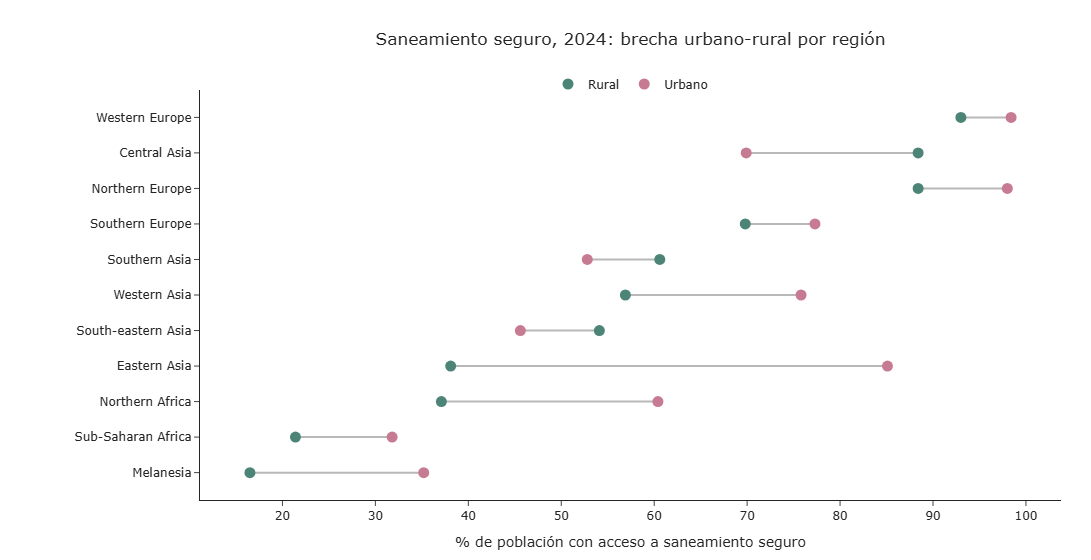

In [10]:
df_brecha = regiones_ancho[
    (regiones_ancho["Año"] == 2024) &
    (regiones_ancho["Indicador"] == "Saneamiento") &
    (regiones_ancho["Entidad"].isin(nombres_subregion))  # Solo subregiones (un único nivel M49)
].dropna(subset=["Urbano", "Rural"]).copy()

df_brecha["Brecha"] = df_brecha["Urbano"] - df_brecha["Rural"]
df_brecha = df_brecha.sort_values("Rural", ascending=True)

fig2 = go.Figure()

for _, row in df_brecha.iterrows():
    fig2.add_trace(go.Scatter(
        x=[row["Rural"], row["Urbano"]], y=[row["Entidad"], row["Entidad"]],
        mode="lines", line=dict(color=PALETA["gris"], width=2),
        showlegend=False, hoverinfo="skip",))

fig2.add_trace(go.Scatter(
    x=df_brecha["Rural"], y=df_brecha["Entidad"], mode="markers", name="Rural",
    marker=dict(color=PALETA["rural"], size=11),
    hovertemplate="%{y} — Rural: %{x:.1f}%<extra></extra>",))
fig2.add_trace(go.Scatter(
    x=df_brecha["Urbano"], y=df_brecha["Entidad"], mode="markers", name="Urbano",
    marker=dict(color=PALETA["urbano"], size=11),
    hovertemplate="%{y} — Urbano: %{x:.1f}%<extra></extra>",))

fig2.update_layout(
    template=TEMPLATE, height=560, width=920,
    title=dict(text="Saneamiento seguro, 2024: brecha urbano-rural por región", x=0.5, xanchor="center", xref="paper"),
    xaxis_title="% de población con acceso a saneamiento seguro",
    yaxis_title=None,
    legend=dict(orientation="h", y=1.05, x=0.5, xanchor="center"),
    margin=dict(t=90, l=200, r=30, b=50),)
fig2.show()

## Gráfico 3: Ranking de regiones por saneamiento seguro en 2024

**Principios aplicados:**
- **Barras > gráficos de pastel para precisión** (Cleveland & McGill): comparar 24 categorías por ángulo/área sería impreciso; la posición en un eje común lo resuelve.
- **Punto Focal** (Treisman & Gelade): la barra correspondiente al promedio mundial se resalta en el color de acento; el resto queda en gris neutro para no competir por atención.
- **Confinamiento** (Wertheimer): no se dibuja un marco/cuadro alrededor del gráfico, las barras ya forman una "gestalt" completa por sí solas.
- **Reducción de "chartjunk"** (Tufte): sin líneas de cuadrícula verticales innecesarias, sin sombreados 3D.

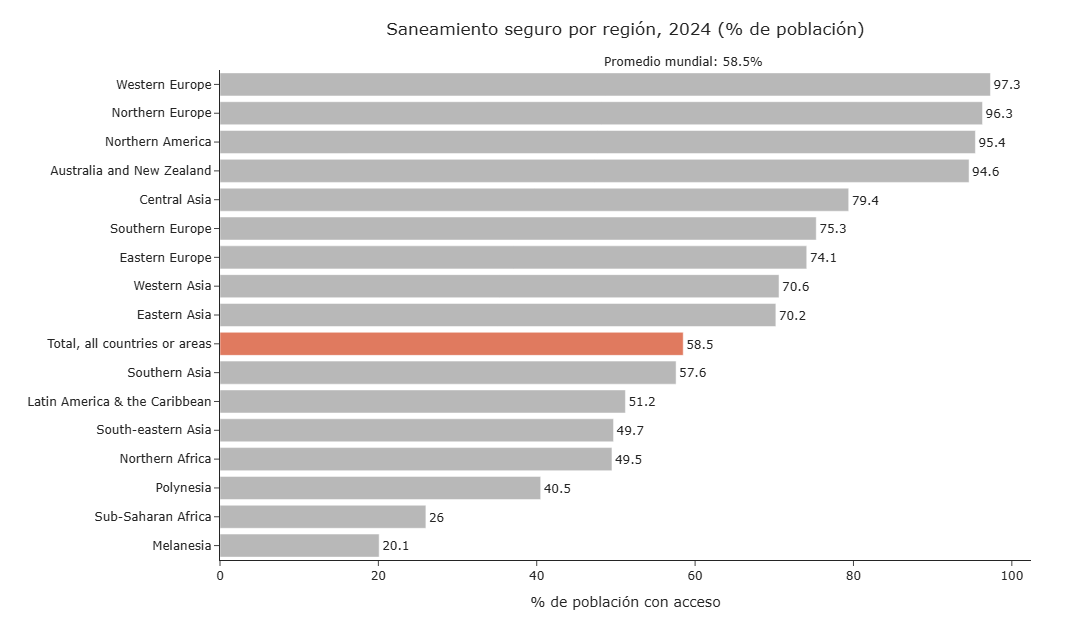

In [11]:
df_rank = regiones_ancho[
    (regiones_ancho["Año"] == 2024) & (regiones_ancho["Indicador"] == "Saneamiento") &
    # Solo subregiones (un único nivel M49) + el total mundial como referencia
    (regiones_ancho["Entidad"].isin(nombres_subregion | {"Total, all countries or areas"}))
].dropna(subset=["Total"]).copy()
df_rank = df_rank.sort_values("Total", ascending=True)

promedio_mundial = df_rank.loc[df_rank["Entidad"] == "Total, all countries or areas", "Total"].values[0]
colores_barra = [PALETA["acento"] if e == "Total, all countries or areas" else PALETA["gris"] for e in df_rank["Entidad"]]

fig3 = go.Figure(go.Bar(
    x=df_rank["Total"], y=df_rank["Entidad"], orientation="h",
    marker_color=colores_barra,
    text=df_rank["Total"].round(1), textposition="outside",
    hovertemplate="%{y}: %{x:.1f}%<extra></extra>",
    hoverlabel=dict(bgcolor=colores_barra, font=dict(color="white", size=13)),))
fig3.add_vline(x=promedio_mundial, line_dash="dot", line_color=PALETA["acento"],
                annotation_text=f"Promedio mundial: {promedio_mundial:.1f}%", annotation_position="top")

fig3.update_layout(
    template=TEMPLATE, height=620, width=920,
    title=dict(text="Saneamiento seguro por región, 2024 (% de población)", x=0.5, xanchor="center", xref="paper"),
    xaxis_title="% de población con acceso", yaxis_title=None,
    margin=dict(t=70, l=220, r=60, b=50), showlegend=False,)
fig3.show()

## Gráfico 4: Mapa mundial de acceso al agua potable en 2024

**Principios aplicados:**
- **Ley de Correspondencia Isomórfica** (Köhler): se usa un mapa geográfico real en lugar de, por ejemplo, un treemap de países que respeta el modelo mental que la audiencia ya tiene del mundo, cumpliendo la recomendación de "ceñirse a las convenciones establecidas".
- **Escala de color secuencial de un solo matiz** (Cynthia Brewer / ColorBrewer): variación de `PALETA["agua"]` para representar una variable continua y ordenada que evita las escalas arcoíris que distorsionan la percepción de magnitud.

**Nota sobre países que no aparecen en el mapa:**

1. **31 países sin dato específico** para 2024 (Agua potable, Total) en la base JMP de la ONU, entre ellos economías grandes como Australia, China, Kenia o Arabia Saudita. El CSV no tiene fila con ese año/serie, así que nunca llegan a `df_mapa`.
2. **2 países con nombre desactualizado en la librería de Plotly**, `"Eswatini"` y `"Türkiye"`. Plotly usa internamente el paquete `country-regex` para reconocer nombres de país, y ese paquete todavía busca los nombres antiguos (`"swaziland"`, `"turkey"`), no los oficiales actuales. Se corrigió esto solo para el mapa, se agrega una columna auxiliar `Entidad_Plotly` únicamente en `df_mapa`, que traduce el nombre solo para el emparejamiento geográfico, el resto del notebook, y el propio texto que aparece al pasar el cursor sobre el país en el mapa, siguen usando el nombre oficial ("Eswatini"). Sobre Türkiye, como no tiene dato en la fuente para 2024, sigue sin aparecer en el mapa.

C:\Users\letit\AppData\Local\Temp\ipykernel_15552\922282210.py:9: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig4 = px.choropleth(


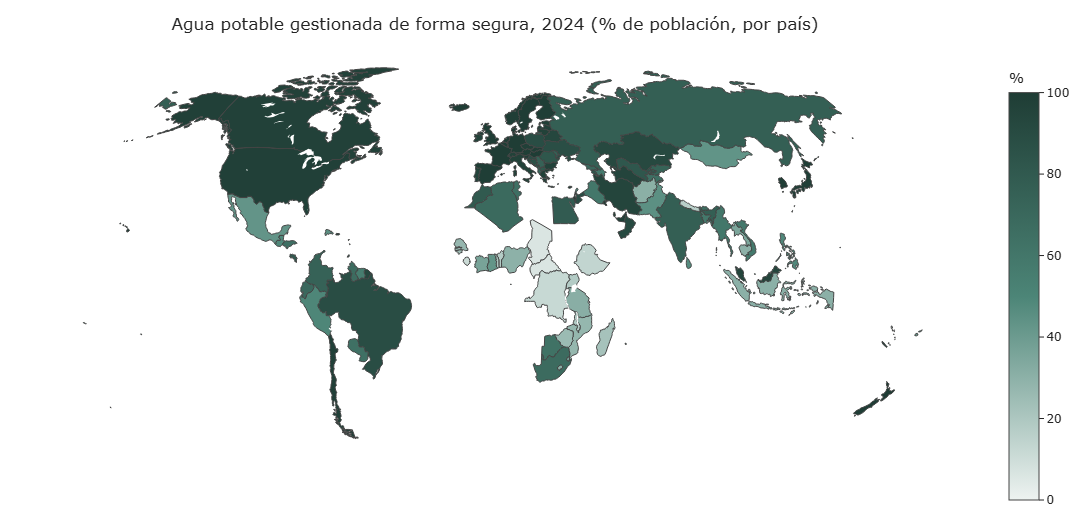

In [12]:
df_mapa = df_paises[
    (df_paises["Año"] == 2024) & (df_paises["Indicador"] == "Agua potable") & (df_paises["Zona"] == "Total")
].dropna(subset=["Cobertura"])

# Corrección para reconocer Eswatini y Türkiye en el mapa
nombres_plotly = {"Eswatini": "Swaziland", "Türkiye": "Turkey"}
df_mapa["Entidad_Plotly"] = df_mapa["Entidad"].replace(nombres_plotly)

fig4 = px.choropleth(
    df_mapa, locations="Entidad_Plotly", locationmode="country names", color="Cobertura",
    color_continuous_scale=["#eef3f1", PALETA["agua"], "#1f3d35"],
    range_color=(0, 100),
    hover_name="Entidad", # nombre oficial mostrado en pantalla, no se ve afectado por el reemplazo
    labels={"Cobertura": "% con acceso"},
    hover_data={"Entidad_Plotly": False, "Cobertura": ":.1f"},
)
fig4.update_layout(
    template=TEMPLATE, height=520, width=980,
    title=dict(text="Agua potable gestionada de forma segura, 2024 (% de población, por país)", x=0.5, xanchor="center", xref="paper"),
    margin=dict(t=60, l=10, r=10, b=10),
    coloraxis_colorbar=dict(title="%"),
)
fig4.update_geos(showframe=False, showcoastlines=False, projection_type="natural earth")
fig4.show()

In [13]:
# Diagnóstico de países del mapa que no se colorean

# Países sin datos
sin_dato_2024 = sorted(
    set(df_paises["Entidad"].unique()) -
    set(df_paises[(df_paises["Año"] == 2024) & (df_paises["Indicador"] == "Agua potable") &
                  (df_paises["Zona"] == "Total")]["Entidad"].unique()))
print(f"• Países sin dato de agua potable total en 2024 (n={len(sin_dato_2024)}):")
print(sin_dato_2024)

# Verificación de la corrección aplicada en columna Entidad_Plotly a países cuyo nombre no coincide con la librería interna de Plotly (country-regex):
print("\n• Corrección de nombre de país aplicada solo al mapa (Entidad original no se modifica):")
for nombre_oficial in ["Eswatini", "Türkiye"]:
    tiene_dato = nombre_oficial in df_mapa["Entidad"].values
    if tiene_dato:
        nombre_usado_en_mapa = df_mapa.loc[df_mapa["Entidad"] == nombre_oficial, "Entidad_Plotly"].values[0]
        print(f" - {nombre_oficial}: Sí tiene dato 2024 → se pinta en el mapa usando el nombre "
              f"'{nombre_usado_en_mapa}' (el hover sigue mostrando '{nombre_oficial}')")
    else:
        print(f" - {nombre_oficial}: No tiene dato 2024 en la fuente → seguirá sin pintarse")

• Países sin dato de agua potable total en 2024 (n=31):
['Argentina', 'Australia', 'Burkina Faso', 'China', 'Comoros', 'Congo', 'Cuba', "Dem. People's Rep. Korea", 'Djibouti', 'El Salvador', 'Greenland', 'Grenada', 'Guernsey', 'Jamaica', 'Kenya', 'Libya', 'Mali', 'Mauritius', 'Mayotte', 'Niger', 'Panama', 'Papua New Guinea', 'Rwanda', 'Saudi Arabia', 'Somalia', 'Thailand', 'Türkiye', 'Uruguay', 'Venezuela (Boliv. Rep. of)', 'Yemen', 'Zambia']

• Corrección de nombre de país aplicada solo al mapa (Entidad original no se modifica):
 - Eswatini: Sí tiene dato 2024 → se pinta en el mapa usando el nombre 'Swaziland' (el hover sigue mostrando 'Eswatini')
 - Türkiye: No tiene dato 2024 en la fuente → seguirá sin pintarse


## Gráfico 5: Evolución de la brecha en el tiempo, 2010-2024

**Principios aplicados:**
- **Gráfico de diferencias en vez de comparar curvas** (Cleveland): en vez superponer Urbano y Rural como dos líneas que el lector debe restar mentalmente, se grafica la diferencia de `Urbano − Rural` a través del tiempo.
- **Pequeños múltiplos en vez de barras apiladas** (Cleveland & McGill): cada región es un panel propio con eje compartido, en lugar de amontonar 8 regiones en una sola barra apilada.
- **Prägnanz** (Wertheimer): los datos se ordenan por brecha final, de mayor a menor, para presentar el patrón de la forma más simple y lógica posible.

**Selección de las 8 regiones mostradas:** se muestran las **8 subregiones con mayor brecha urbano-rural real en 2024** (calculado en la celda siguiente), no una selección arbitraria — y todas al mismo nivel jerárquico (subregión), sin mezclar continentes completos con subregiones dentro del mismo panel de comparación.

Subregiones con dato completo (Urbano y Rural) en 2024: 11
['Eastern Asia', 'Northern Africa', 'Western Asia', 'Melanesia', 'Sub-Saharan Africa', 'Northern Europe', 'Southern Europe', 'Western Europe', 'Southern Asia', 'South-eastern Asia', 'Central Asia']



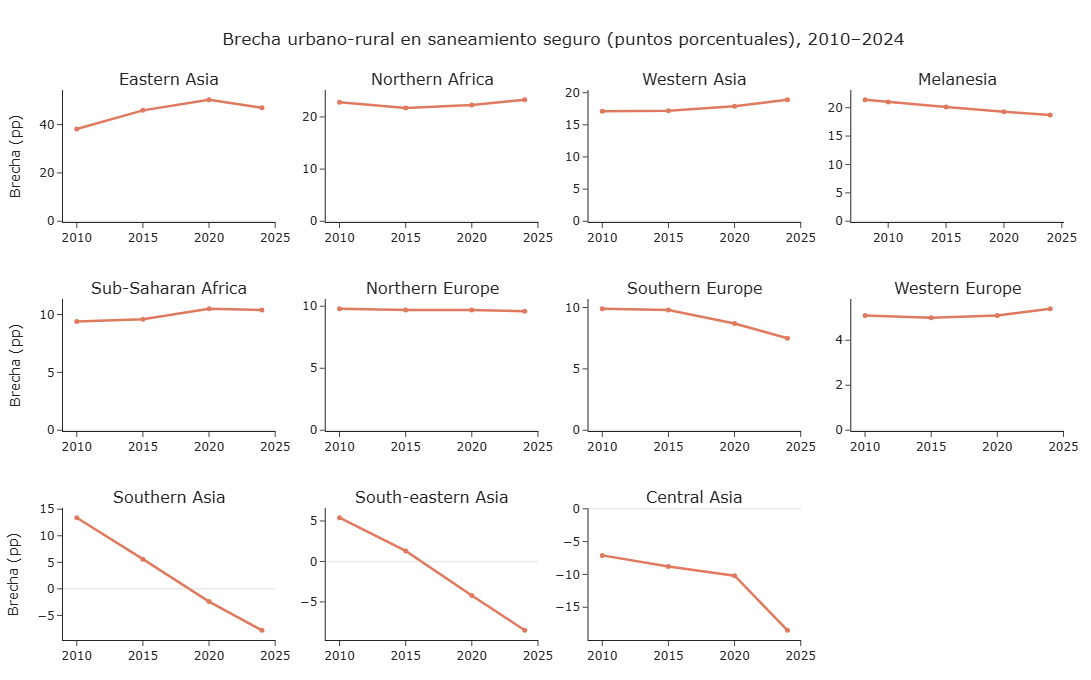

In [14]:
df_dif_todas = regiones_ancho[
    (regiones_ancho["Entidad"].isin(nombres_subregion)) & (regiones_ancho["Indicador"] == "Saneamiento")
].dropna(subset=["Urbano", "Rural"]).copy()
df_dif_todas["Brecha"] = df_dif_todas["Urbano"] - df_dif_todas["Rural"]

año_max = df_dif_todas["Año"].max()
regiones_interes = (
    df_dif_todas[df_dif_todas["Año"] == año_max]
    .sort_values("Brecha", ascending=False)["Entidad"].tolist()
)
print(f"Subregiones con dato completo (Urbano y Rural) en {año_max}: {len(regiones_interes)}")
print(regiones_interes)
print()

df_dif = df_dif_todas[df_dif_todas["Entidad"].isin(regiones_interes)].copy()
orden = regiones_interes  # ya viene ordenado de mayor a menor brecha

# Cuadrícula 3x4 (12 espacios) para las 11 regiones
fig5 = make_subplots(rows=3, cols=4, subplot_titles=orden, vertical_spacing=0.14, horizontal_spacing=0.05)
posiciones = [(1,1),(1,2),(1,3),(1,4),(2,1),(2,2),(2,3),(2,4),(3,1),(3,2),(3,3)]

for (r, c), region in zip(posiciones, orden):
    sub = df_dif[df_dif["Entidad"] == region].sort_values("Año")
    fig5.add_trace(
        go.Scatter(x=sub["Año"], y=sub["Brecha"], mode="lines+markers",
                    line=dict(color=PALETA["acento"], width=2.5), marker=dict(size=5),
                    showlegend=False, hovertemplate="%{x}: %{y:.1f} pp<extra></extra>"),
        row=r, col=c,
    )
    # Curzar la línea en y=0 indica que el patrón urbano-rural se invierte (rural supera a urbano)
    fig5.add_hline(y=0, line_color=PALETA["gris"], line_width=1.5, row=r, col=c)

fig5.update_yaxes(title_text="Brecha (pp)", row=1, col=1)
fig5.update_yaxes(title_text="Brecha (pp)", row=2, col=1)
fig5.update_yaxes(title_text="Brecha (pp)", row=3, col=1)
fig5.update_layout(
    template=TEMPLATE, height=680, width=1080,
    title=dict(text="Brecha urbano-rural en saneamiento seguro (puntos porcentuales), 2010–2024", x=0.5, xanchor="center", xref="paper"),
    margin=dict(t=90, l=60, r=20, b=40),
)
fig5.show()

# 3. Dashboard interactivo (Plotly + Dash)

Se construye un tablero interactivo que permite a la audiencia explorar por sí misma:

- **Indicador:** Agua potable / Saneamiento
- **Zona:** Urbano / Rural / Total
- **Año:** para el mapa mundial (slider 2010-2024)
- **Región:** para resaltar una región específica en el ranking

El código completo se guarda también como script independiente `dash_app.py` para ejecutarse fuera del notebook con:

```bash
python dash_app.py
```

y abrir `http://127.0.0.1:8050` en el navegador. (No se ejecuta el servidor dentro de esta celda para no bloquear la evaluación del notebook; la celda siguiente solo **define** la app y confirma que se construye sin errores.)

**Principios de diseño del dashboard:**
- **Similaridad** (Wertheimer): mismos colores/paleta que el resto del notebook.
- **Proximidad** (Wertheimer): controles agrupados en la parte superior y gráficos agrupados debajo.
- **Punto Focal** (Treisman & Gelade): un único color de acento por vista controlado por el usuario.

In [24]:
import dash
from dash import dcc, html, Input, Output

app = dash.Dash(__name__)
app.title = "Agua y Saneamiento — Dashboard"

indicadores = sorted(regiones_ancho["Indicador"].unique())
zonas = ["Urbano", "Rural", "Total"]
regiones_dashboard = sorted(nombres_subregion)  # solo subregiones (un único nivel M49)
anios = sorted(int(a) for a in df_paises["Año"].unique())  # int nativo: numpy.int64 rompe el JSON del Slider

app.layout = html.Div(style={"fontFamily": "Helvetica, Arial, sans-serif", "padding": "24px",
                              "backgroundColor": "#fbfbfa"}, children=[

    html.H2("Acceso mundial a agua y saneamiento seguros (2010–2024)",
            style={"color": PALETA["total"]}),
    html.P("Explora la tendencia global, el ranking regional y el mapa mundial de cobertura.",
           style={"color": "#666"}),

    html.Div(style={"display": "flex", "gap": "24px", "flexWrap": "wrap", "marginBottom": "20px"}, children=[
        html.Div([
            html.Label("Indicador"),
            dcc.Dropdown(id="dd-indicador", options=[{"label": i, "value": i} for i in indicadores],
                         value="Saneamiento", clearable=False, style={"width": "260px"}),
        ]),
        html.Div([
            html.Label("Región a destacar"),
            dcc.Dropdown(id="dd-region", options=[{"label": r, "value": r} for r in regiones_dashboard] + 
                         [{"label": "Total, all countries or areas", "value": "Total, all countries or areas"}],
                         value="Total, all countries or areas", clearable=False, style={"width": "260px"}),
        ]),
        html.Div([
            html.Label("Año (mapa mundial)"),
            dcc.Slider(id="sl-anio", min=min(anios), max=max(anios),
                       value=max(anios), step=None,
                       marks={a: str(a) for a in anios}),
        ], style={"width": "420px"}),
    ]),

    html.Div(style={"display": "flex", "gap": "20px", "flexWrap": "wrap"}, children=[
        dcc.Graph(id="graf-tendencia", style={"flex": "1", "minWidth": "460px"}),
        dcc.Graph(id="graf-ranking", style={"flex": "1", "minWidth": "460px"}),
    ]),
    dcc.Graph(id="graf-mapa"),
])


@app.callback(Output("graf-tendencia", "figure"), Input("dd-indicador", "value"), Input("dd-region", "value"))
def actualizar_tendencia(indicador, region):
    sub_global = regiones_ancho[(regiones_ancho["Entidad"] == "Total, all countries or areas") &
                                 (regiones_ancho["Indicador"] == indicador)].sort_values("Año")
    sub_region = regiones_ancho[(regiones_ancho["Entidad"] == region) &
                                 (regiones_ancho["Indicador"] == indicador)].sort_values("Año")
    fig = go.Figure()
    for zona in zonas:
        fig.add_trace(go.Scatter(x=sub_global["Año"], y=sub_global[zona], mode="lines",
                                   line=dict(color=colores_zona[zona], width=2, dash="dot"),
                                   name=f"Mundial – {zona}", opacity=0.5))
    for zona in zonas:
        fig.add_trace(go.Scatter(x=sub_region["Año"], y=sub_region[zona], mode="lines+markers",
                                   line=dict(color=colores_zona[zona], width=3),
                                   name=f"{region} – {zona}"))
    fig.update_layout(template=TEMPLATE, title=f"Tendencia: {region} vs. mundial ({indicador})",
                       yaxis_title="% de población", yaxis_range=[0, 100],
                       legend=dict(orientation="h", y=-0.25))
    return fig


@app.callback(Output("graf-ranking", "figure"), Input("dd-indicador", "value"), Input("dd-region", "value"))
def actualizar_ranking(indicador, region):
    d = regiones_ancho[(regiones_ancho["Año"] == 2024) & (regiones_ancho["Indicador"] == indicador) &
                        (regiones_ancho["Entidad"].isin(nombres_subregion | {"Total, all countries or areas"}))]
    d = d.dropna(subset=["Total"]).sort_values("Total")
    colores = [PALETA["acento"] if e == region else PALETA["gris"] for e in d["Entidad"]]
    fig = go.Figure(go.Bar(x=d["Total"], y=d["Entidad"], orientation="h", marker_color=colores))
    fig.update_layout(template=TEMPLATE, title=f"Ranking regional 2024 ({indicador})",
                       xaxis_title="% de población", margin=dict(l=200))
    return fig


@app.callback(Output("graf-mapa", "figure"), Input("dd-indicador", "value"), Input("sl-anio", "value"))
def actualizar_mapa(indicador, anio):
    d = df_paises[(df_paises["Año"] == anio) & (df_paises["Indicador"] == indicador) &
                  (df_paises["Zona"] == "Total")].dropna(subset=["Cobertura"])
    fig = px.choropleth(d, locations="Entidad", locationmode="country names", color="Cobertura",
                         color_continuous_scale=["#eef3f1", PALETA["agua"], "#1f3d35"], range_color=(0, 100),
                         hover_name="Entidad")
    fig.update_layout(template=TEMPLATE, title=f"{indicador} seguro, {anio} (% por país)",
                       margin=dict(t=50, l=10, r=10, b=10))
    fig.update_geos(showframe=False, showcoastlines=False, projection_type="natural earth")
    return fig


print("Dashboard construido correctamente:", len(app.callback_map), "callbacks registrados.")
print("Para lanzarlo: ejecuta `python dash_app.py` en una terminal y abre http://127.0.0.1:8050")

Dashboard construido correctamente: 3 callbacks registrados.
Para lanzarlo: ejecuta `python dash_app.py` en una terminal y abre http://127.0.0.1:8050


cd /d D:\Regina\DataScience\Notebooks\Tarea 57. Water and Sanitation
dash_app.py

> **Nota técnica:** la celda anterior solo define la app; no llama a `app.run()` ahí para no bloquear el resto del notebook. La celda siguiente sí la ejecuta, con `jupyter_mode="external"` que levanta el servidor local y muestra un link para abrirlo en un navegador. El archivo `dash_app.py` contiene el mismo código más el bloque `if __name__ == "__main__": app.run(debug=True)`, para ejecutarse también de forma independiente en una terminal.

In [23]:
app.run(jupyter_mode="external", port=8050)

OSError: Address 'http://127.0.0.1:8050' already in use.
    Try passing a different port to run.

C:\Users\letit\AppData\Local\Temp\ipykernel_15552\1638910124.py:85: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(d, locations="Entidad", locationmode="country names", color="Cobertura",
C:\Users\letit\AppData\Local\Temp\ipykernel_15552\1638910124.py:85: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(d, locations="Entidad", locationmode="country names", color="Cobertura",


## 4. Conclusiones: ¿qué nos dicen los datos?

1. **El acceso global mejora, pero el promedio mundial oculta desigualdades importantes**: entre 2010 y 2024, la cobertura mundial de saneamiento gestionado de forma segura aumentó de 41.5% a 58.5%, un avance de 17 puntos porcentuales. Sin embargo, la mejora no se distribuye de manera uniforme: en 2024, el acceso a sanemaniento urbano alcanzó 65.8%, mientras que el rural se situó en 48.5% (Gráfico 1).
2. **La brecha urbano-rural es importante, pero no es universal**: en la mayoría de las subregiones analizadas, la cobertura urbana supera a la rural; sin embargo, el Gráfico 2 revela excepciones relevantes: Asia Sudoriental, Asia Meridional y Asia Central presentan una cobertura rural superior a la urbana en 2024. Esto muestra que la desigualdad territorial no sigue un único patrón y que las diferencias regionales requieren un análisis más cuidadoso.
3. **La evolución de la brecha es heterogénea**: no todas las regiones avanzan de la misma manera. El Gráfico 5 muestra que algunas regiones reducen progresivamente su brecha urbano-rural, mientras que otras la mantienen relativamente estable o incluso la amplían. Además, en algunas regiones la diferencia cambia de signo, pasando de una ventaja urbana a una ventaja rural. Por ello, el progreso global no implica necesariamente que la desigualdad territorial se esté reduciendo en todas partes.
4. **La desigualdad también es geográfica y se observa con claridad a nivel de país**: el mapa de 2024 muestra una amplia variación en el acceso a agua potable gestionada de forma segura, mientras varios países presentan coberturas cercanas al 100%, otros se encuentran por debajo del 40%, especialmente en distintos países de África Subsahariana y algunas zonas de Asia y Oceanía. Esta lectura debe interpretarse considerando que 31 países no cuentan con un dato específico para 2024 en la fuente utilizada y, por tanto, no aparecen coloreados en el mapa.

En conjunto, la historia que cuentan los datos no es simplemente que el mundo está mejorando, sino que el avance global convive con desigualdades territoriales persistentes y patrones regionales distintos. El promedio mundial sirve como punto de partida, pero son las diferencias entre regiones y entre zonas urbanas y rurales las que permiten comprender dónde persisten los mayores desafíos.